In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/test.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/17f6c7072f61.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0243404e8a00.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0083ee8054ee.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0ac436400db4.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0d0a21fd354f.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/02da652c74b8.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/15e96e848b46.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/059bc89df7f4.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/04d029cfb612.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_ima

In [2]:
# ============================================================
# SECTION 1 — EXPLORATION DES DONNÉES (EDA)
# Projet PFA : Détection intelligente de la rétinopathie diabétique
# Dataset   : APTOS 2019 Blindness Detection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité — obligatoire pour un projet académique
np.random.seed(42)

# ── Chemins Kaggle ──────────────────────────────────────────
# Vérifier d'abord avec : os.listdir('/kaggle/input/')
BASE_PATH = '/kaggle/input/datasets/mariaherrerot/aptos2019'         # adapter si besoin
TRAIN_CSV  = os.path.join(BASE_PATH, 'train_1.csv')
TEST_CSV   = os.path.join(BASE_PATH, 'test.csv')
TRAIN_DIR  = os.path.join(BASE_PATH, 'train_images', 'train_images')
TEST_DIR   = os.path.join(BASE_PATH, 'test_images',  'test_images')

# ── Nommage clinique des classes ─────────────────────────────
CLASS_NAMES = {
    0: 'No DR',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}
COLORS = ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#8e44ad']

In [3]:
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print("╔══════════════════════════════════════╗")
print("║     AUDIT DU DATASET APTOS 2019      ║")
print("╚══════════════════════════════════════╝\n")

print(f"  Lignes train     : {len(df_train)}")
print(f"  Lignes test      : {len(df_test)}")
print(f"  Colonnes train   : {list(df_train.columns)}")
print(f"  Valeurs manquan. : {df_train.isnull().sum().to_dict()}")
print(f"  Doublons         : {df_train.duplicated().sum()}")
print(f"\nAperçu :")
display(df_train.head(8))

print(f"\nRépartition par classe :")
for label, count in df_train['diagnosis'].value_counts().sort_index().items():
    pct = count / len(df_train) * 100
    bar = '█' * int(pct / 2)
    print(f"  Classe {label} ({CLASS_NAMES[label]:18s}) : {count:4d}  {bar} {pct:.1f}%")

╔══════════════════════════════════════╗
║     AUDIT DU DATASET APTOS 2019      ║
╚══════════════════════════════════════╝

  Lignes train     : 2930
  Lignes test      : 366
  Colonnes train   : ['id_code', 'diagnosis']
  Valeurs manquan. : {'id_code': 0, 'diagnosis': 0}
  Doublons         : 0

Aperçu :


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0
5,1b4625877527,2
6,1b495ac025b7,3
7,1b862fb6f65d,0



Répartition par classe :
  Classe 0 (No DR             ) : 1434  ████████████████████████ 48.9%
  Classe 1 (Mild DR           ) :  300  █████ 10.2%
  Classe 2 (Moderate DR       ) :  808  █████████████ 27.6%
  Classe 3 (Severe DR         ) :  154  ██ 5.3%
  Classe 4 (Proliferative DR  ) :  234  ███ 8.0%


# PHASE 2:  Préprocessing & Augmentation

## Cellule 1 - Imports de la phase 2

In [4]:
# ============================================================
# SECTION 2 — PRÉPROCESSING & AUGMENTATION
# ============================================================

import cv2
import numpy as np
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os

# ── Hyperparamètres de la phase ─────────────────────────────
IMG_SIZE    = 224      # 224 pour benchmark, 380 pour EfficientNet-B4 final
BATCH_SIZE  = 32
NUM_WORKERS = 2        # sur Kaggle, 2 est une valeur sûre
VAL_FOLD    = 0        # fold utilisé comme validation (StratifiedKFold)
N_FOLDS     = 5

## Cellule 2 - Circle crop

In [5]:
def crop_image_from_gray(img, tol=7):
    """
    Supprime les bandes noires autour de la rétine.
    
    La rétinographie est circulaire : les bords de l'image sont noirs 
    (hors du champ optique). Ces pixels noirs ne contiennent aucune 
    information pathologique et biaisent l'apprentissage.
    
    Paramètre tol : seuil d'intensité en dessous duquel un pixel 
    est considéré comme 'vide'. 7 est empiriquement robuste sur APTOS.
    """
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    
    elif img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > tol
        
        # Vérification de sécurité : si l'image est trop sombre,
        # on retourne l'image originale sans crop
        check = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        if check.shape[0] == 0 or check.shape[1] == 0:
            return img
        
        img_cropped = img[np.ix_(mask.any(1), mask.any(0))]
        return img_cropped

## Cellule 3 - Ben Graham preprocessing

In [6]:
def ben_graham_preprocessing(img, sigmaX=30):
    """
    Préprocessing de Ben Graham — vainqueur Kaggle DR Competition 2015.
    
    Principe mathématique :
        output = α × img + β × GaussianBlur(img, σ) + γ
        avec α=4, β=-4, γ=128
    
    Ce que ça fait concrètement :
    ┌─────────────────────────────────────────────────────────┐
    │  GaussianBlur(img) ≈ composante basse fréquence        │
    │  (illumination globale, vignettage, gradients lents)   │
    │                                                         │
    │  img - GaussianBlur(img) = composante haute fréquence  │
    │  (microanévrismes, exsudats, bords de vaisseaux)       │
    │                                                         │
    │  ×4 + 128 → ramène dans [0, 255] avec contraste exagéré│
    └─────────────────────────────────────────────────────────┘
    
    Pourquoi sigmaX=30 ?
    À 30px sur une image 256-512px, le flou couvre les variations
    d'illumination régionales sans effacer les micro-structures.
    Valeur issue du papier original et validée sur APTOS dans 
    plusieurs publications arxiv 2020-2023.
    """
    img = cv2.addWeighted(
        img,                                    # image originale  (α = 4)
        4,
        cv2.GaussianBlur(img, (0, 0), sigmaX), # image floutée    (β = -4)
        -4,
        128                                     # offset γ = 128 (centre à 128)
    )
    return img

## Cellule 4 - CLAHE

In [7]:
def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    CLAHE — Contrast Limited Adaptive Histogram Equalization.
    
    Différence avec l'égalisation d'histogramme classique (HE) :
    ┌──────────────────┬──────────────────────────────────────┐
    │ HE global        │ Égalise sur toute l'image → amplifie │
    │                  │ le bruit dans les zones sombres      │
    ├──────────────────┼──────────────────────────────────────┤
    │ CLAHE            │ Divise l'image en tiles (ici 8×8),   │
    │                  │ égalise localement avec une limite   │
    │                  │ de contraste → préserve les détails  │
    │                  │ locaux sans sur-amplifier le bruit   │
    └──────────────────┴──────────────────────────────────────┘
    
    Pourquoi travailler en LAB ?
    L'espace LAB sépare la luminosité (L) des informations de 
    couleur (A, B). On applique CLAHE uniquement sur L → on 
    améliore le contraste sans altérer les couleurs, qui portent 
    une information pathologique (rouge des hémorragies, jaune 
    des exsudats).
    
    Paramètres :
      clip_limit=2.0    → limite l'amplification du contraste
                          (évite d'amplifier le bruit)
      tile_grid_size=8  → 8×8 = 64 tuiles locales sur l'image
    """
    # Convertir RGB → LAB
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    
    # Séparer les canaux
    l_channel, a_channel, b_channel = cv2.split(img_lab)
    
    # Appliquer CLAHE sur le canal L uniquement
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    l_clahe = clahe.apply(l_channel)
    
    # Recombiner les canaux
    img_lab_clahe = cv2.merge([l_clahe, a_channel, b_channel])
    
    # Reconvertir LAB → RGB
    img_rgb = cv2.cvtColor(img_lab_clahe, cv2.COLOR_LAB2RGB)
    return img_rgb

## Cellule 5 -  Pipeline complet de chargement

In [8]:
def load_and_preprocess(img_id, directory, size=IMG_SIZE,
                        use_ben_graham=True, use_clahe=True,
                        sigmaX=30):
    """
    Pipeline de chargement complet pour une image APTOS.
    
    Ordre des opérations (important — l'ordre change le résultat) :
      1. Lecture BGR → conversion RGB
      2. Circle crop (supprime le fond noir)
      3. Ben Graham (rehausse les structures locales)
      4. CLAHE (améliore le contraste local)
      5. Resize vers la taille cible
    
    Note : CLAHE après Ben Graham car Ben Graham peut créer des
    artefacts d'intensité que CLAHE atténue ensuite.
    """
    # ── 1. Lecture ───────────────────────────────────────────
    img = None
    for ext in ['.png', '.jpeg', '.jpg']:
        path = os.path.join(directory, img_id + ext)
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                break
    
    if img is None:
        # Image manquante → retourne une image noire (ne crash pas)
        return np.zeros((size, size, 3), dtype=np.uint8)
    
    # ── 2. Circle crop ───────────────────────────────────────
    img = crop_image_from_gray(img)
    
    # Redimensionner pour que Ben Graham ait une base cohérente
    img = cv2.resize(img, (size, size))
    
    # ── 3. Ben Graham ────────────────────────────────────────
    if use_ben_graham:
        img = ben_graham_preprocessing(img, sigmaX=sigmaX)
        # Garantir que les valeurs restent dans [0, 255]
        img = np.clip(img, 0, 255).astype(np.uint8)
    
    # ── 4. CLAHE ─────────────────────────────────────────────
    if use_clahe:
        img = apply_clahe(img)
    
    return img.astype(np.uint8)

## Cellule 6 -  Visualisation comparative du preprocessing

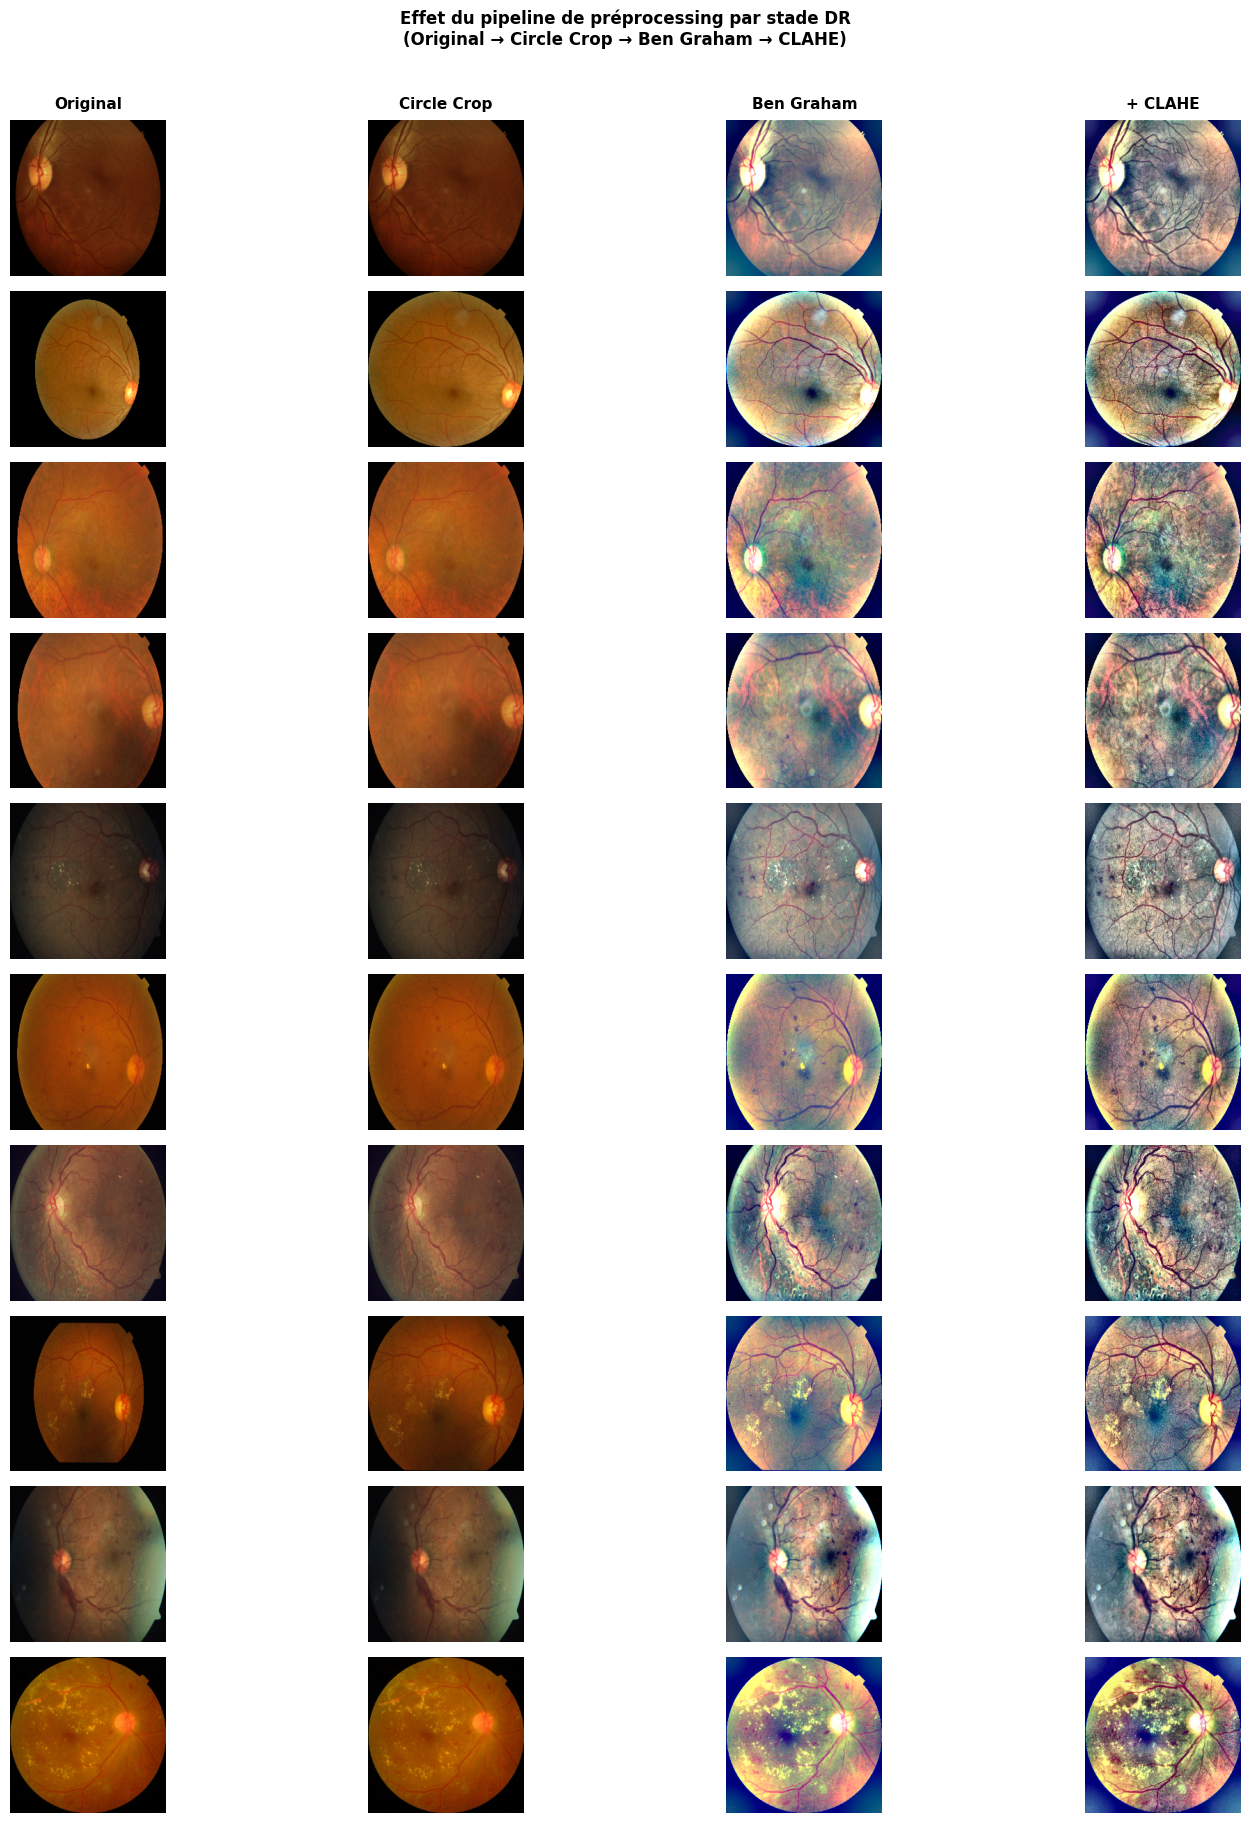

In [9]:
def visualize_preprocessing_pipeline(df, directory, n_per_class=2):
    """
    Affiche côte à côte l'image originale, après Ben Graham, et après CLAHE.
    Indispensable pour le notebook : montre visuellement l'effet de chaque étape.
    """
    fig, axes = plt.subplots(
        5 * n_per_class, 4,
        figsize=(16, 5 * n_per_class * 1.8)
    )
    fig.suptitle(
        'Effet du pipeline de préprocessing par stade DR\n'
        '(Original → Circle Crop → Ben Graham → CLAHE)',
        fontsize=12, fontweight='bold', y=1.01
    )
    
    col_titles = ['Original', 'Circle Crop', 'Ben Graham', '+ CLAHE']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    
    CLASS_COLORS = ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#8e44ad']
    CLASS_NAMES  = {0:'No DR', 1:'Mild', 2:'Moderate', 3:'Severe', 4:'Proliferative'}
    
    row_idx = 0
    for label in range(5):
        samples = df[df['diagnosis'] == label].sample(
            min(n_per_class, len(df[df['diagnosis'] == label])),
            random_state=42
        )
        for _, row in samples.iterrows():
            # Charger l'image originale
            img_orig = None
            for ext in ['.png', '.jpeg', '.jpg']:
                path = os.path.join(directory, row['id_code'] + ext)
                if os.path.exists(path):
                    img_orig = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
                    break
            
            if img_orig is None:
                row_idx += 1
                continue
            
            # Les 4 étapes
            img_resize = cv2.resize(img_orig, (IMG_SIZE, IMG_SIZE))
            img_crop   = cv2.resize(crop_image_from_gray(img_orig), (IMG_SIZE, IMG_SIZE))
            img_bg     = np.clip(ben_graham_preprocessing(img_crop), 0, 255).astype(np.uint8)
            img_clahe  = apply_clahe(img_bg)
            
            images = [img_resize, img_crop, img_bg, img_clahe]
            
            for col_idx, im in enumerate(images):
                ax = axes[row_idx][col_idx]
                ax.imshow(im)
                ax.axis('off')
                # Colorier la bordure selon la classe
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_edgecolor(CLASS_COLORS[label])
                    spine.set_linewidth(2.5)
            
            # Label de la classe sur la première colonne
            axes[row_idx][0].set_ylabel(
                f'Classe {label}\n{CLASS_NAMES[label]}',
                fontsize=9, fontweight='bold',
                rotation=0, labelpad=70, va='center',
                color=CLASS_COLORS[label]
            )
            row_idx += 1
    
    plt.tight_layout()
    plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
    plt.show()

# Appel
df_train = pd.read_csv(TRAIN_CSV)
visualize_preprocessing_pipeline(df_train, TRAIN_DIR, n_per_class=2)